In [1]:
# ==========================================================
# Cell 1 : Imports
# ==========================================================

import os
import sys
import time
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# Cell 2 : Project Paths
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "processed_data"

MODEL_DIR = PROJECT_ROOT / "saved_models"

RESULT_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULT_DIR / "metrics"
HISTORY_DIR = RESULT_DIR / "history"

MODEL_DIR.mkdir(exist_ok=True)

RESULT_DIR.mkdir(exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

C:\Users\ashut\Documents\Rainfall Prediction


In [3]:
# ==========================================================
# Cell 3 : Device
# ==========================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Device : cuda
NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
# ==========================================================
# Cell 4 : Load Dataset
# ==========================================================

X_train = np.load(PROCESSED_DIR / "X_train.npy")

y_train = np.load(PROCESSED_DIR / "y_train.npy")

X_val = np.load(PROCESSED_DIR / "X_val.npy")

y_val = np.load(PROCESSED_DIR / "y_val.npy")

X_test = np.load(PROCESSED_DIR / "X_test.npy")

y_test = np.load(PROCESSED_DIR / "y_test.npy")

print(X_train.shape)
print(y_train.shape)

(6387, 7, 129, 135)
(6387, 129, 135)


In [5]:
# ==========================================================
# Cell 5 : Create Dataset
# ==========================================================

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.dataset import RainfallDataset

train_dataset = RainfallDataset(X_train, y_train)

val_dataset = RainfallDataset(X_val, y_val)

test_dataset = RainfallDataset(X_test, y_test)

print("Datasets Created Successfully!")

Datasets Created Successfully!


In [6]:
# ==========================================================
# Cell 6 : DataLoader
# ==========================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Train Batches : 799
Validation Batches : 172
Test Batches : 172


In [7]:
# ==========================================================
# Cell 7 : Import Model
# ==========================================================

from models.cnn_bilstm import CNNBiLSTM

print("CNN + BiLSTM Imported Successfully!")

CNN + BiLSTM Imported Successfully!


In [8]:
# ==========================================================
# Cell 8 : Build CNN + BiLSTM
# ==========================================================

cnn_bilstm = CNNBiLSTM().to(DEVICE)

print(cnn_bilstm)

CNNBiLSTM(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (bilstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (regressor): Sequential(
    (0): Linear(in_features=256, out_fea

In [9]:
# ==========================================================
# Cell 9 : Loss Function
# ==========================================================

criterion = nn.MSELoss()

print("Loss Function :", criterion)

Loss Function : MSELoss()


In [10]:
# ==========================================================
# Cell 10 : Optimizer
# ==========================================================

LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(
    cnn_bilstm.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer Initialized!")

Optimizer Initialized!


In [11]:
# ==========================================================
# Cell 11 : Early Stopping
# ==========================================================

from utils.early_stopping import EarlyStopping

early_stopping = EarlyStopping(
    patience=5,
    delta=0
)

print("EarlyStopping Initialized!")

EarlyStopping Initialized!


In [12]:
# ==========================================================
# Cell 12 : Training Configuration
# ==========================================================

EPOCHS = 30

history = {
    "train_loss": [],
    "val_loss": []
}

best_loss = float("inf")

print("Training Configuration Ready!")

Training Configuration Ready!


In [13]:
# ==========================================================
# Cell 12A : Import Training Utilities
# ==========================================================

from utils.trainer import (
    train_one_epoch,
    validate
)

print("Training Utilities Imported Successfully!")

Training Utilities Imported Successfully!


In [14]:
# ==========================================================
# Debug Cell : Verify Tensor Shapes
# ==========================================================

images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

frame = images[:, 0]

print("Single Frame Shape :", frame.shape)

output = cnn_bilstm(frame.unsqueeze(1)) if False else None

Images Shape : torch.Size([8, 7, 1, 129, 135])
Labels Shape : torch.Size([8, 1, 129, 135])
Single Frame Shape : torch.Size([8, 1, 129, 135])


In [15]:
# ==========================================================
# Cell 13 : CNN + BiLSTM Training
# ==========================================================

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        cnn_bilstm,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss = validate(
        cnn_bilstm,
        val_loader,
        criterion,
        DEVICE
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            cnn_bilstm.state_dict(),
            MODEL_DIR / "cnn_bilstm.pth"
        )

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print(f"\nEarly stopping at Epoch {epoch+1}")

        break

Epoch 01/30 | Train Loss: 0.000037 | Val Loss: 0.000032
Epoch 02/30 | Train Loss: 0.000030 | Val Loss: 0.000030
Epoch 03/30 | Train Loss: 0.000030 | Val Loss: 0.000031
Epoch 04/30 | Train Loss: 0.000029 | Val Loss: 0.000031
Epoch 05/30 | Train Loss: 0.000029 | Val Loss: 0.000031
Epoch 06/30 | Train Loss: 0.000029 | Val Loss: 0.000030
Epoch 07/30 | Train Loss: 0.000029 | Val Loss: 0.000030
Epoch 08/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 09/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 10/30 | Train Loss: 0.000029 | Val Loss: 0.000030
Epoch 11/30 | Train Loss: 0.000029 | Val Loss: 0.000031
Epoch 12/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 13/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 14/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 15/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 16/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 17/30 | Train Loss: 0.000029 | Val Loss: 0.000029
Epoch 18/30 | Train Loss: 0.000029 | Val Loss: 0

In [16]:
cnn_bilstm.load_state_dict(
    torch.load(
        MODEL_DIR / "cnn_bilstm.pth",
        map_location=DEVICE
    )
)

cnn_bilstm.eval()

print("Best CNN + BiLSTM Model Loaded!")

Best CNN + BiLSTM Model Loaded!


In [17]:
predictions = []
targets = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(DEVICE)

        pred = cnn_bilstm(X)

        predictions.append(pred.cpu().numpy())
        targets.append(y.numpy())

print("Prediction Completed!")

Prediction Completed!


In [18]:
y_pred = np.concatenate(predictions, axis=0)
y_true = np.concatenate(targets, axis=0)

print("Prediction Shape :", y_pred.shape)
print("Ground Truth Shape :", y_true.shape)

Prediction Shape : (1369, 1, 129, 135)
Ground Truth Shape : (1369, 1, 129, 135)


In [20]:
# ==========================================================
# Import Evaluation Utilities
# ==========================================================

from utils.metrics import (
    evaluate_model,
    print_metrics
)

print("Evaluation Utilities Imported Successfully!")

Evaluation Utilities Imported Successfully!


In [21]:
metrics = evaluate_model(
    y_true,
    y_pred
)

print_metrics(metrics)

MAE     : 0.001329
MSE     : 0.000032
RMSE    : 0.005696
R2      : 0.246329


In [22]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    HISTORY_DIR / "cnn_bilstm_training_history.csv",
    index=False
)

print("Training history saved!")

Training history saved!


In [23]:
metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    METRICS_DIR / "cnn_bilstm_metrics.csv",
    index=False
)

print("Metrics saved!")

Metrics saved!


In [26]:
# ==========================================================
# Create Figures Directory
# ==========================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURE_DIR)

C:\Users\ashut\Documents\Rainfall Prediction\figures


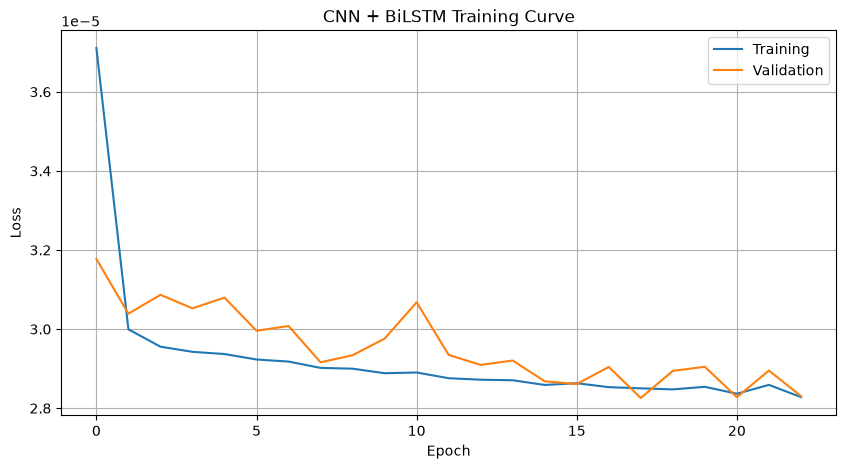

In [27]:
plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Training")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + BiLSTM Training Curve")

plt.grid(True)
plt.legend()

plt.savefig(
    FIGURE_DIR / "cnn_bilstm_training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

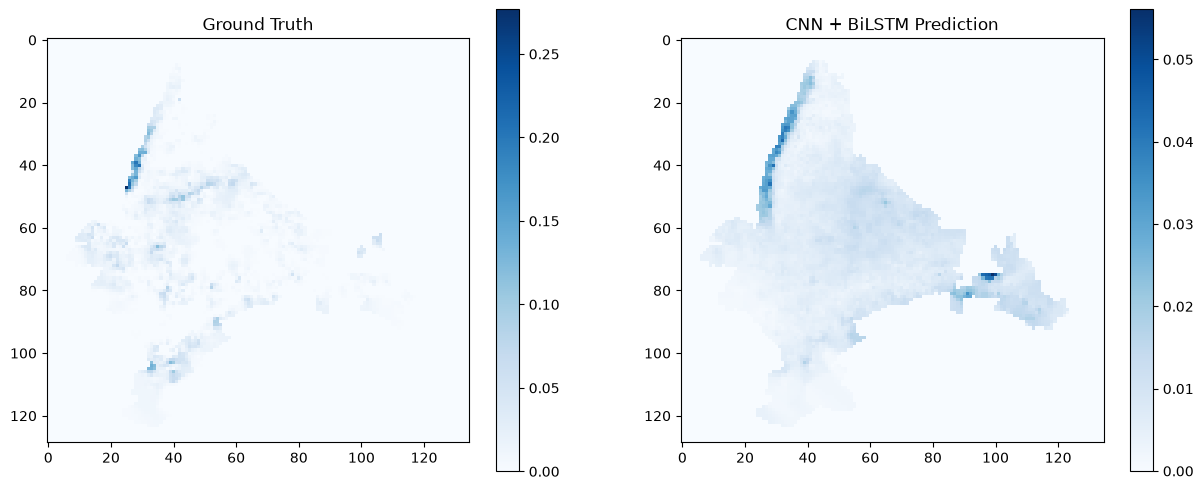

In [28]:
sample = 100

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)

plt.imshow(
    y_true[sample][0],
    cmap="Blues"
)

plt.title("Ground Truth")
plt.colorbar()

plt.subplot(1,2,2)

plt.imshow(
    y_pred[sample][0],
    cmap="Blues"
)

plt.title("CNN + BiLSTM Prediction")
plt.colorbar()

plt.savefig(
    FIGURE_DIR / "cnn_bilstm_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

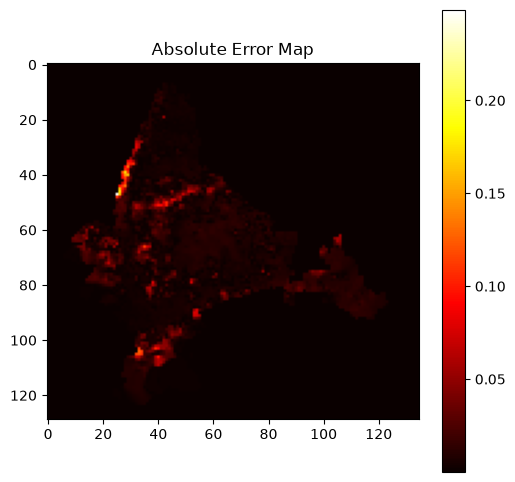

In [29]:
difference = np.abs(
    y_true[sample][0] -
    y_pred[sample][0]
)

plt.figure(figsize=(6,6))

plt.imshow(
    difference,
    cmap="hot"
)

plt.title("Absolute Error Map")
plt.colorbar()

plt.savefig(
    FIGURE_DIR / "cnn_bilstm_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
print("="*60)
print("Notebook 3 Completed Successfully!")
print("="*60)

print(f"MAE  : {metrics['MAE']:.6f}")
print(f"MSE  : {metrics['MSE']:.6f}")
print(f"RMSE : {metrics['RMSE']:.6f}")
print(f"R2   : {metrics['R2']:.6f}")

print("\nSaved Files:")
print("✔ cnn_bilstm.pth")
print("✔ history/cnn_bilstm_training_history.csv")
print("✔ metrics/cnn_bilstm_metrics.csv")
print("✔ figures/cnn_bilstm_training_curve.png")
print("✔ figures/cnn_bilstm_prediction.png")
print("✔ figures/cnn_bilstm_error.png")

print("\nNotebook 3 Finished!")

Notebook 3 Completed Successfully!
MAE  : 0.001329
MSE  : 0.000032
RMSE : 0.005696
R2   : 0.246329

Saved Files:
✔ cnn_bilstm.pth
✔ cnn_bilstm_training_history.csv
✔ cnn_bilstm_metrics.csv
✔ cnn_bilstm_training_curve.png
✔ cnn_bilstm_prediction.png
✔ cnn_bilstm_error.png

Notebook 3 Finished!
